### The following function will process a raw wav audio and isolate the keystrokes into PyTorch array

    - Credit to the original authors: Joshua Harrison et Al
    - Reference: https://github.com/JBFH-Dev/Keystroke-Datasets/blob/main/README.md

### Logic Flow

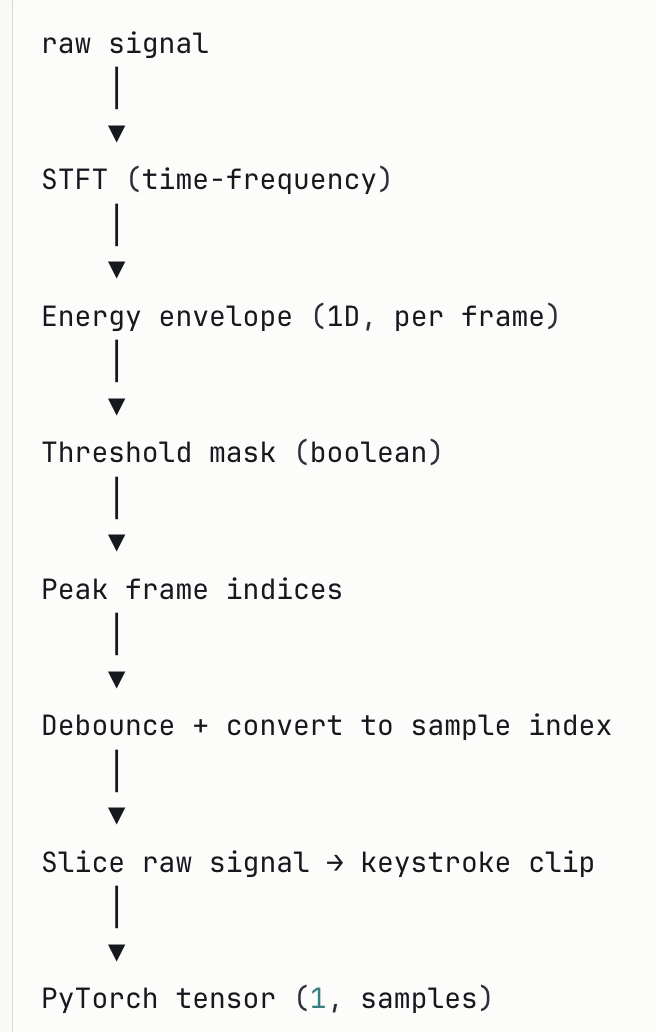

In [1]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import torch
import os
import wave
from scipy.io import wavfile
import soundfile as sf

def RecordingKeyStrokesIsolator(rawAudioSignal: np.array, sampleRate: int, FFTWindowSize: int, scan: int, before, after, threshold, outPutDir, cleanFilePath, show=False):
    """
    Description: Isolating the keystroke sound from a raw audio recording and display the keystroke in PyTorch array.
    :param rawAudioSignal: The raw audio as numpy array
    :param sampleRate: The sample rate of the audio recording
    :param FFTWindowSize: FFT window size
    :param scan: Hop length - how many samples to slide the FFT window each step
    :param before: Sample captured before the detected peak
    :param after: Sample captured after the detected peak
    :param threshold: Energy level above which something is considered a keystroke
    :param outPutDir: The output directory to write all the extracted keystrokes
    :param cleanFilePath: The file path to save audio file of all extracted keystrokes
    :param show: Show waveforms at each stage
    :return: A PyTorch tensor of the isolated keystroke audio
    """
    
    strokes = []
    """Showing The Original Audio Signal"""
    if show:
        plt.figure(figsize=(7, 2))
        librosa.display.waveshow(rawAudioSignal, sr=sampleRate)
        plt.title("Original Audio Signal")
        plt.show()
        plt.close()
    
    """Running a Short-Time Fourier Transform To Convert the Audio signal into a 2D array of shape (frequency_bins, time_frames)"""
    fft = librosa.stft(rawAudioSignal, n_fft=FFTWindowSize, hop_length=scan)
   
    """Collapse all frequency bins to a single value per time frame, then take the magnitude to form a 1D energy envelope over time, this will show an array of all the high peaks in the audio signal"""
    energy = np.abs(np.sum(fft, axis=0)).astype(float)
    if show:
        plt.figure(figsize=(7, 2))
        librosa.display.waveshow(energy)
        plt.title("Energy Peaks")
        plt.show()
        plt.close()

    """Initializing a boolean array that marks True if the peak in the energy array is above the pre-defined threshold value, otherwise False"""
    threshed = energy > threshold
    if show:
        plt.figure(figsize=(7, 2))
        librosa.display.waveshow(threshed.astype(float))
        plt.title(f"Energy Peaks above the threshold value {threshold}")
        plt.show()
        plt.close()

    """Finds all time frame in the original wav signal that that the peak energy is above the threshold"""
    peaks = np.where(threshed == True)[0]
    peak_count = len(peaks)

    """Initializes prev_end to a negative value. This is to ensure the very first peak always passes the minimum gap"""
    prev_end = sampleRate * 0.1 * (-1)

    """Begin insolating the keystroke signal from the audio"""
    for i in range(peak_count):
        """Getting the current peak in the array"""
        this_peak = peaks[i]
        """Getting the timestamp in the original audio that the peak is located"""
        timestamp = (this_peak * scan) + FFTWindowSize // 2
        """Applied a rule to accept the peak as a new keystroke, if it's at least 100ms after the previous keystroke ended. This prevents duplicate detection of the same keystroke"""
        if timestamp > prev_end + (0.1 * sampleRate):
            """Slices the original audio around the detected timestamp"""
            keystroke = rawAudioSignal[timestamp - before:timestamp + after]
            strokes.append(torch.tensor(keystroke)[None, :])

            if not os.path.exists(outPutDir):
                os.mkdir(outPutDir)       
            """Saving each keystroke detected to an output directory"""
            filename = f"{outPutDir}{len(strokes)}.wav"
            """Writing the detected keystroke as a wave file"""
            sf.write(
                filename,
                keystroke,
                sampleRate,
                subtype='PCM_16'
            )
            if show:
                plt.figure(figsize=(7, 2))
                librosa.display.waveshow(keystroke, sr=sampleRate)
                plt.title(f"Keystroke {len(strokes)}")
                plt.show()
                plt.close()
        
        """Update the prev_end to the end of the current keystroke window to ensure the next keystroke is being detected accurately"""
        prev_end = timestamp + after

    print(f"Isolated {len(strokes)} keystrokes → saved to {os.path.abspath(outPutDir)}")

    """Saving all detected keystrokes into a single wave file"""
    """Creating pauses in between each detected keystroke"""
    silenceSamples = int(sampleRate * 200 / 1000)
    silence = np.zeros(silenceSamples, dtype=np.float32)
    clips = []
    for i, stroke in enumerate(strokes):
        clip = stroke.squeeze(0).numpy()
        clips.append(clip)
        if i < len(strokes) - 1: # No trailing silence after last keystroke
            clips.append(silence) #Adding the pause after each key strokes
    combined = np.concatenate(clips, axis=0)
    sf.write(
        cleanFilePath,
        combined,
        sampleRate,
        subtype='PCM_16'
    )
    print(f"Combined WAV saved → {cleanFilePath} ({len(combined)/sampleRate:.2f}s)")        
    """Return a list of PyTorch tensors of the clean keystrokes signal from the recording"""
    return strokes    

### Testing The Function

Sample rate: 48000 Hz
Audio data shape: (507904,)
Audio data type: int16


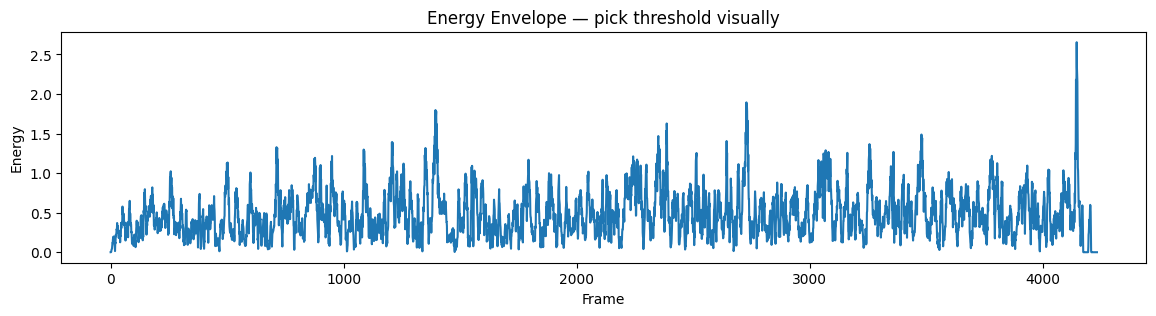

Min:     0.0
Max:     2.6546175479888916
Mean:    0.48171259800279015
Median:  0.43186768889427185
Std:     0.29355366496265


In [2]:
# audioData, sampleRate = librosa.load("a-z0-9.wav", mono=True, sr=None)
sampleRate, audioData = wavfile.read("0-9.wav")

print(f"Sample rate: {sampleRate} Hz")
print(f"Audio data shape: {audioData.shape}")
print(f"Audio data type: {audioData.dtype}")

"""Convert audio signal to float32 - Reason because stft only accept float32 dtype"""
audioData = audioData.astype(np.float32) / np.iinfo(np.int16).max

"""Convert stereo to mono"""
if audioData.ndim == 2:
    audioData = np.mean(audioData, axis=1)

"""Assume a keystroke sound is 5-20ms long"""
FFTWindowSize = int(sampleRate * 0.02)
scan = FFTWindowSize // 8 # <- Smaller sliding to capture as much keystrokes as possible, tradeoff longer execution and more computing resources exhausted

before = int(sampleRate * 0.02)   # 20ms
after  = int(sampleRate * 0.08)   # 80ms

# Step 1: Plot the energy envelope and visually inspect
fft = librosa.stft(audioData, n_fft=FFTWindowSize, hop_length=scan)
energy = np.abs(np.sum(fft, axis=0)).astype(float)

plt.figure(figsize=(14, 3))
plt.plot(energy)
plt.title("Energy Envelope — pick threshold visually")
plt.ylabel("Energy")
plt.xlabel("Frame")
plt.show()

# Step 2: Check the distribution
print("Min:    ", energy.min())
print("Max:    ", energy.max())
print("Mean:   ", energy.mean())
print("Median: ", np.median(energy))
print("Std:    ", energy.std())

# Step 3: A good starting threshold is usually:
threshold = energy.mean() + 2 * energy.std()


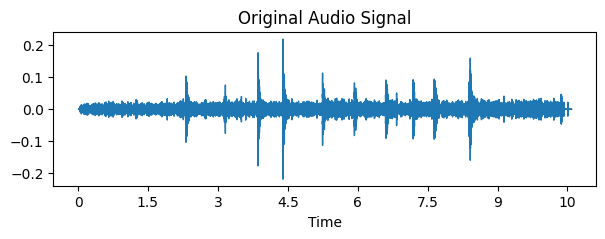

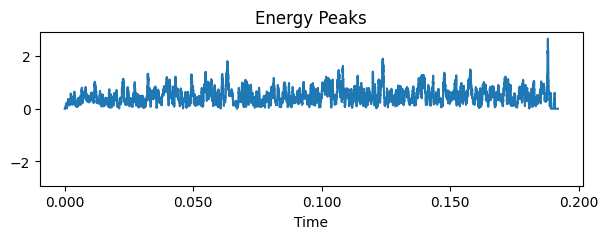

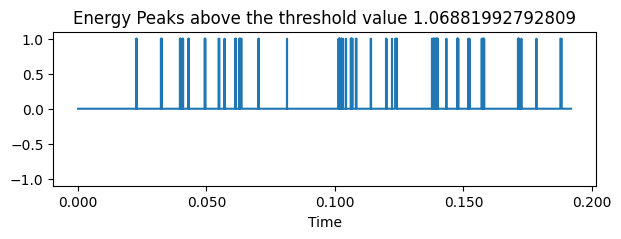

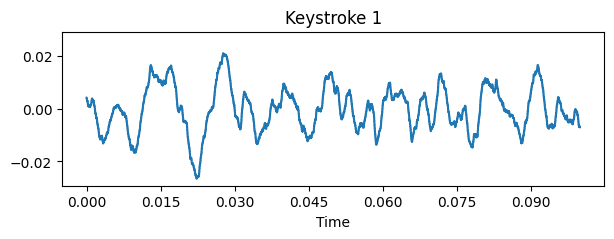

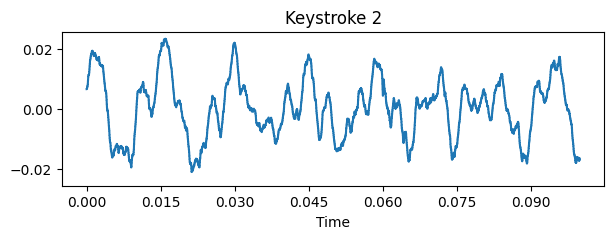

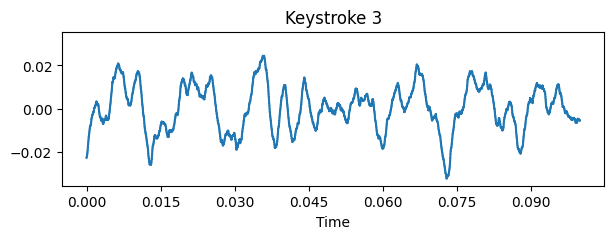

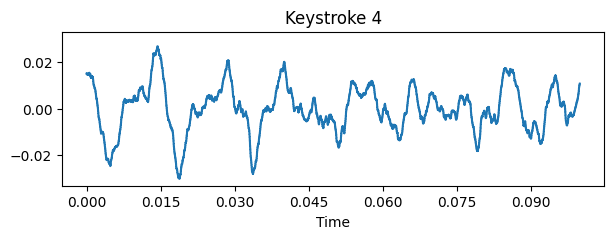

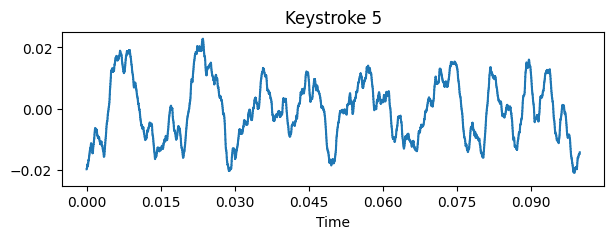

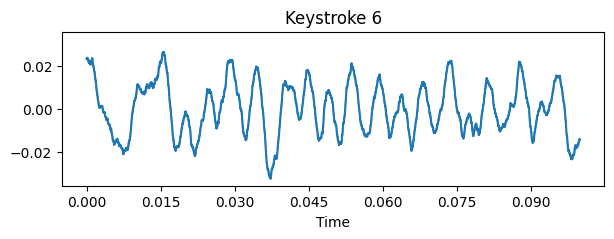

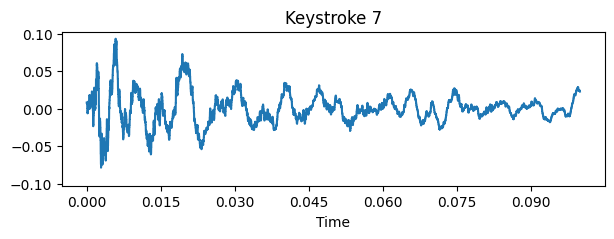

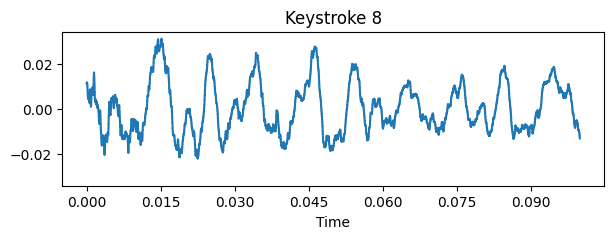

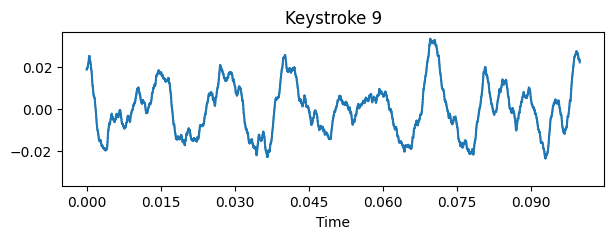

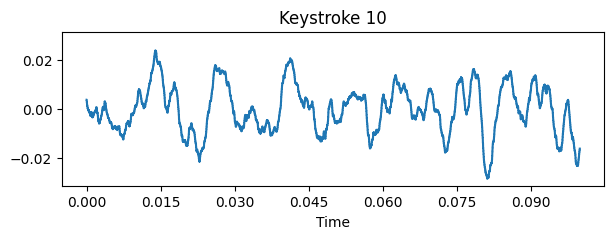

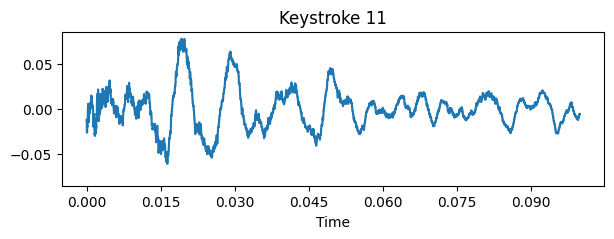

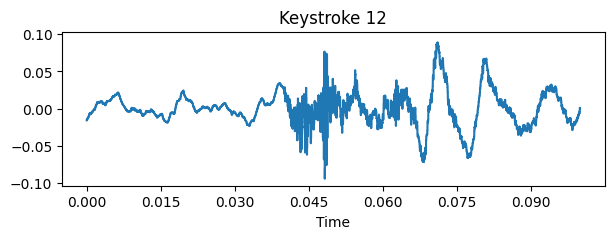

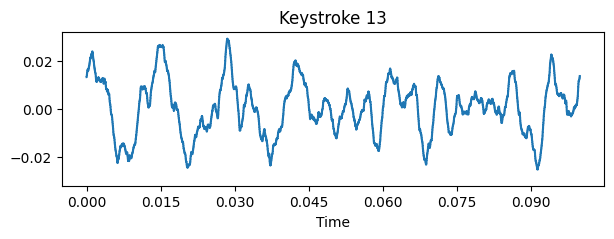

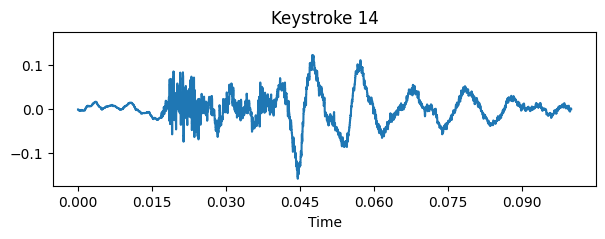

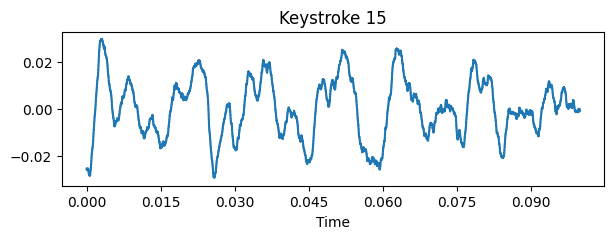

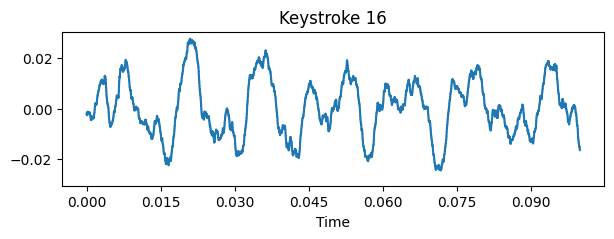

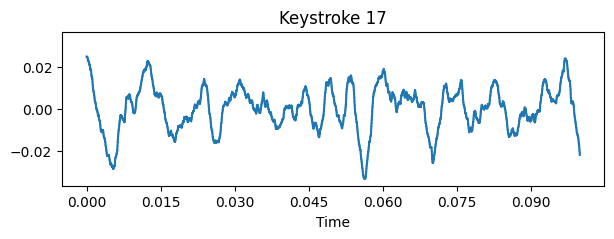

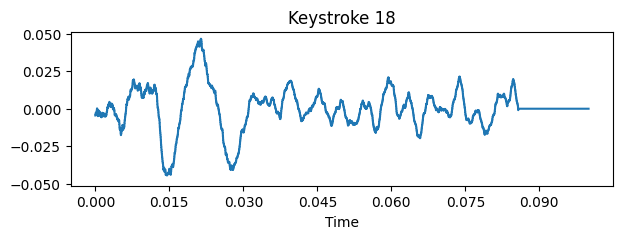

Isolated 18 keystrokes → saved to /Users/davidnguyen/PycharmProjects/MachineLearningProjects/Keyboard -ASCA/AudioPreprocessing/0-9
Combined WAV saved → 0-9-clean.wav (5.20s)


[tensor([[ 0.0042,  0.0039,  0.0036,  ..., -0.0067, -0.0070, -0.0070]]),
 tensor([[ 0.0065,  0.0066,  0.0066,  ..., -0.0168, -0.0167, -0.0166]]),
 tensor([[-0.0227, -0.0223, -0.0220,  ..., -0.0054, -0.0055, -0.0055]]),
 tensor([[0.0150, 0.0151, 0.0150,  ..., 0.0105, 0.0106, 0.0108]]),
 tensor([[-0.0197, -0.0197, -0.0196,  ..., -0.0146, -0.0143, -0.0142]]),
 tensor([[ 0.0230,  0.0232,  0.0234,  ..., -0.0142, -0.0140, -0.0140]]),
 tensor([[0.0082, 0.0079, 0.0070,  ..., 0.0238, 0.0232, 0.0229]]),
 tensor([[ 0.0113,  0.0113,  0.0115,  ..., -0.0122, -0.0125, -0.0132]]),
 tensor([[0.0186, 0.0187, 0.0187,  ..., 0.0226, 0.0223, 0.0220]]),
 tensor([[ 0.0037,  0.0030,  0.0026,  ..., -0.0168, -0.0167, -0.0164]]),
 tensor([[-0.0123, -0.0169, -0.0261,  ..., -0.0064, -0.0059, -0.0057]]),
 tensor([[-0.0156, -0.0149, -0.0144,  ..., -0.0008,  0.0004,  0.0010]]),
 tensor([[0.0132, 0.0135, 0.0141,  ..., 0.0131, 0.0135, 0.0136]]),
 tensor([[-0.0017, -0.0020, -0.0021,  ...,  0.0008,  0.0005, -0.0009]]),
 t

In [3]:
RecordingKeyStrokesIsolator(audioData, sampleRate, FFTWindowSize, scan, before, after, threshold, "./0-9/", "0-9-clean.wav", show=True)

In [ ]:
for dirpath, _, filenames in os.walk("./CombinedDataset"):
    for filename in sorted(filenames):
        if filename.endswith(".wav"):
            filepath = os.path.join(dirpath, filename)
            print(f"Reading audio file at path {filepath}")
            audioData, sampleRate = librosa.load(filepath, mono=True, sr=None)
            audioData = audioData.astype(np.float32) / np.iinfo(np.int16).max
            FFTWindowSize = int(sampleRate * 0.02)
            scan = FFTWindowSize // 8
            before = int(sampleRate * 0.02)
            after  = int(sampleRate * 0.08)
            fft = librosa.stft(audioData, n_fft=FFTWindowSize, hop_length=scan)
            energy = np.abs(np.sum(fft, axis=0)).astype(float)
            threshold = energy.mean() + 2 * energy.std()
            subDir = filename.lower().split('.')[0]
            outputDir = f"./Phone/{subDir}/"
            print(f"Sample rate: {sampleRate} Hz")
            print(f"Audio data shape: {audioData.shape}")
            print(f"Audio data type: {audioData.dtype}")
            print("Min:    ", energy.min())
            print("Max:    ", energy.max())
            print("Mean:   ", energy.mean())
            print("Median: ", np.median(energy))
            print("Std:    ", energy.std())
            plt.figure(figsize=(14, 3))
            plt.plot(energy)
            plt.title("Energy Envelope — pick threshold visually")
            plt.ylabel("Energy")
            plt.xlabel("Frame")
            plt.show()